# CNN для классификации эмоций по выражению лица

Цель ноутбука:
- обучить baseline CNN на датасете FER-2013
- улучшить качество с помощью аугментации данных
- сравнить два подхода по метрикам и кривым обучения

Датасет FER-2013 содержит 35 000 изображений лиц размером 48×48, разбитых на 7 классов эмоций: angry, disgust, fear, happy, sad, surprise, neutral. Датасет несбалансированный — класс disgust содержит в 15+ раз меньше примеров, чем happy.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

## 1. Подготовка данных

### Трансформации

Для baseline — только конвертация в тензор и нормализация в диапазон [-1, 1].  
Для модели с аугментацией — добавляем горизонтальное отражение, небольшие повороты и сдвиги. Эти трансформации сохраняют эмоцию на лице: улыбка остаётся улыбкой независимо от того, повёрнута голова на 5° или отражена по горизонтали.

In [7]:
data_dir = '/kaggle/input/datasets/msambare/fer2013'

BATCH_SIZE = 64
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])   # [0,1] -> [-1,1]
])

aug_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

### Train | Validation | Test split

Из обучающей выборки выделяем 10% на валидацию (для отслеживания переобучения и подбора гиперпараметров).  
Тестовая выборка используется только для финальной оценки.

Для корректного сравнения baseline и augmented модели используем одни и те же индексы разбиения, но разные трансформации: train с аугментацией, val/test без.

In [8]:
# Загружаем два экземпляра train: один с базовыми трансформациями, другой с аугментацией
train_full_base = datasets.ImageFolder(root=f'{data_dir}/train', transform=base_transform)
train_full_aug  = datasets.ImageFolder(root=f'{data_dir}/train', transform=aug_transform)
test_dataset    = datasets.ImageFolder(root=f'{data_dir}/test',  transform=base_transform)

# Генерируем одинаковые индексы для обоих вариантов
val_size = int(0.1 * len(train_full_base))
train_size = len(train_full_base) - val_size

generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(len(train_full_base), generator=generator).tolist()
train_indices = all_indices[:train_size]
val_indices = all_indices[train_size:]

# Baseline: train и val с одинаковыми (базовыми) трансформациями
train_dataset_base = Subset(train_full_base, train_indices)
val_dataset = Subset(train_full_base, val_indices)

# Augmented: train с аугментацией, val без (те же индексы)
train_dataset_aug = Subset(train_full_aug, train_indices)

print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_dataset)}")
print(f"Classes: {train_full_base.classes}")

Train: 25839, Val: 2870, Test: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Распределение классов и примеры из датасета

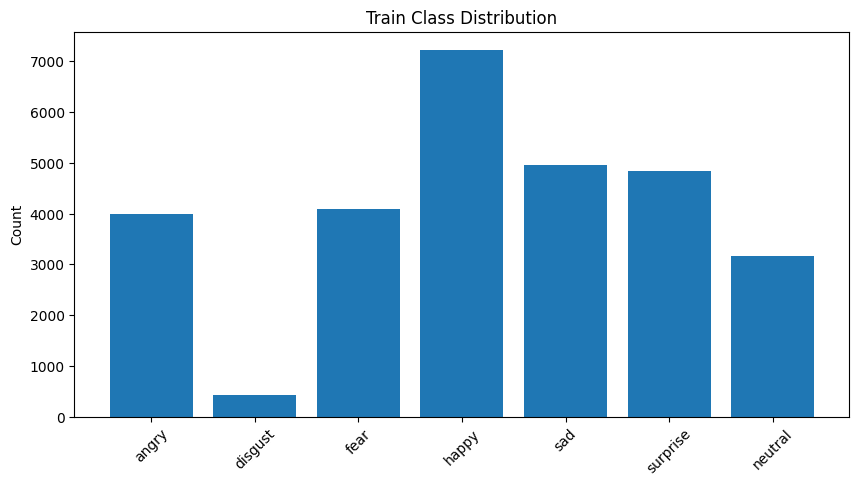

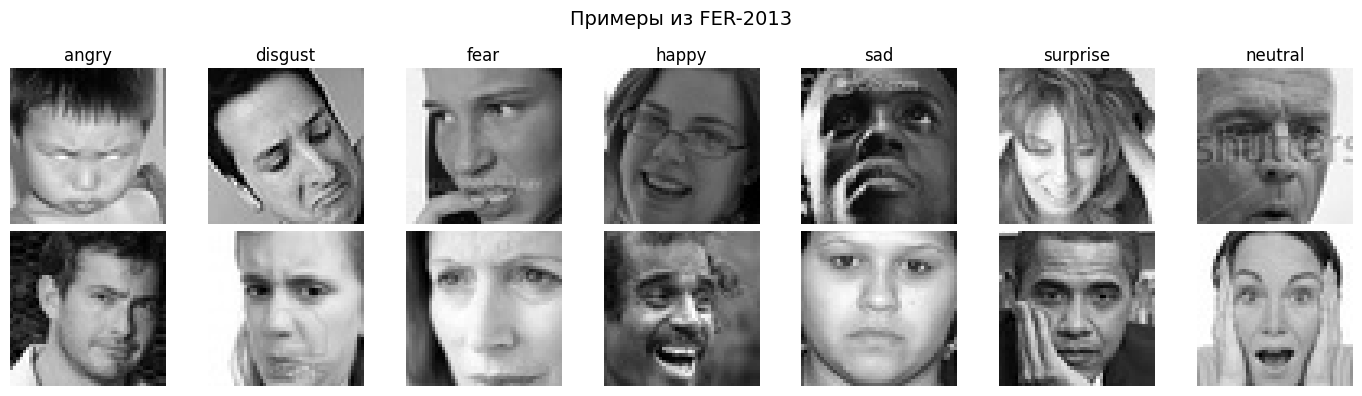

In [9]:
train_labels = [label for _, label in train_full_base]
class_counts = Counter(train_labels)

plt.figure(figsize=(10, 5))
plt.bar(CLASS_NAMES, [class_counts[i] for i in range(7)])
plt.xticks(rotation=45)
plt.title('Train Class Distribution')
plt.ylabel('Count')
plt.show()

fig, axes = plt.subplots(2, 7, figsize=(14, 4))
for class_idx in range(7):
    indices = [i for i, label in enumerate(train_full_base.targets) if label == class_idx][:2]
    for row in range(2):
        img, label = train_full_base[indices[row]]
        axes[row, class_idx].imshow(img.squeeze(), cmap='gray')
        if row == 0:
            axes[row, class_idx].set_title(CLASS_NAMES[class_idx])
        axes[row, class_idx].axis('off')
plt.suptitle('Примеры из FER-2013', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Архитектура

Три свёрточных блока (Conv2d → BatchNorm → ReLU → MaxPool), затем два полносвязных слоя с Dropout.

BatchNorm нормализует активации поканально — стабилизирует обучение и позволяет использовать более высокий learning rate.  
Dropout 50% перед первым FC-слоем — именно там основная масса параметров (~1.2M из ~1.3M), без регуляризации этот слой переобучится первым.  
`bias=False` в свёрточных слоях, потому что BatchNorm имеет свой learnable bias (β), который делает conv bias избыточным.

In [10]:
class SimpleCNN(nn.Module):
    """
    Путь данных:
    (B, 1, 48, 48) -> conv block 1 -> (B, 32, 24, 24)
                    -> conv block 2 -> (B, 64, 12, 12)
                    -> conv block 3 -> (B, 128, 6, 6)
                    -> flatten      -> (B, 4608)
                    -> FC           -> (B, 7)
    """
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 48x48 -> 24x24
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 24x24 -> 12x12
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 12x12 -> 6x6
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# Проверка размерностей
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_test_model = SimpleCNN().to(device)
_dummy = torch.randn(2, 1, 48, 48).to(device)
_out = _test_model(_dummy)
print(f"Input:  {_dummy.shape}")
print(f"Output: {_out.shape}")
print(f"Parameters: {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model, _dummy, _out

Input:  torch.Size([2, 1, 48, 48])
Output: torch.Size([2, 7])
Parameters: 1,274,599


## 3. Обучение

### Функция обучения

Принимает модель и данные, возвращает историю (loss/accuracy на train и val).  
ReduceLROnPlateau уменьшает learning rate вдвое, если val loss не падает 3 эпохи подряд.  
Лучшая модель по val accuracy сохраняется на диск.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, device, epochs=30, lr=1e-3, save_path='best.pth'):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f}")

    print(f"Best Val Accuracy: {best_val_acc:.3f}")
    return history

### Обучаем две модели

Одна и та же архитектура, одни и те же гиперпараметры — различие только в данных.  
Baseline получает оригинальные изображения, augmented — случайно модифицированные.

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- Baseline ---
print("Baseline CNN")
model_baseline = SimpleCNN().to(device)
train_loader_base = DataLoader(train_dataset_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
history_baseline = train_model(
    model_baseline, train_loader_base, val_loader, device,
    epochs=30, save_path='best_baseline.pth'
)

print()

# --- Augmented ---
print('\n')
print("Baseline CNN + Augmentation")
model_augmented = SimpleCNN().to(device)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
history_augmented = train_model(
    model_augmented, train_loader_aug, val_loader, device,
    epochs=30, save_path='best_augmented.pth'
)

Baseline CNN
Epoch  1/30 | Train Loss: 1.6782, Acc: 0.336 | Val Loss: 1.4493, Acc: 0.444
Epoch  5/30 | Train Loss: 1.3073, Acc: 0.496 | Val Loss: 1.2288, Acc: 0.533


## 4. Сравнение экспериментов

### Кривые обучения

Если разрыв между train и val уменьшился после аугментации — значит модель стала лучше обобщать.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train loss
for hist, name in [(history_baseline, 'Baseline'), (history_augmented, 'Augmented')]:
    axes[0].plot(hist['train_loss'], label=name)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train Loss')
axes[0].legend()
axes[0].grid(True)

# Val loss
for hist, name in [(history_baseline, 'Baseline'), (history_augmented, 'Augmented')]:
    axes[1].plot(hist['val_loss'], label=name)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True)

# Val accuracy
for hist, name in [(history_baseline, 'Baseline'), (history_augmented, 'Augmented')]:
    axes[2].plot(hist['val_acc'], label=name)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Train vs Val gap

Отдельно смотрим на разрыв train/val для каждой модели — ключевой индикатор переобучения.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_baseline['train_acc'], label='Train')
ax1.plot(history_baseline['val_acc'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Baseline: Train vs Val Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_augmented['train_acc'], label='Train')
ax2.plot(history_augmented['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Augmented: Train vs Val Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Сводная таблица по валидации

In [ ]:
print(f"{'Model':<25} {'Best Val Acc':>12} {'Final Train Loss':>17} {'Final Val Loss':>15}")
print("-" * 72)
for hist, name in [(history_baseline, 'Baseline'),
                    (history_augmented, 'Augmented')]:
    best_acc = max(hist['val_acc'])
    print(f"{name:<25} {best_acc:>11.4f} {hist['train_loss'][-1]:>17.4f} {hist['val_loss'][-1]:>15.4f}")

## 5. Финальная оценка на тесте

### Classification Report и Confusion Matrix для каждой модели

Загружаем лучшие веса (по val accuracy), оцениваем на тестовой выборке.

In [ ]:
def evaluate_on_test(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds = model(images).argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


# Загружаем лучшие веса
model_baseline.load_state_dict(torch.load('best_baseline.pth'))
model_augmented.load_state_dict(torch.load('best_augmented.pth'))

models = [
    (model_baseline, 'Baseline'),
    (model_augmented, 'Augmented'),
]

test_results = {}

for model, name in models:
    preds, labels = evaluate_on_test(model, test_loader, device)
    test_results[name] = (preds, labels)
    acc = (preds == labels).mean()
    print(f"\n{'=' * 50}")
    print(f"{name} — Test Accuracy: {acc:.4f}")
    print(f"{'=' * 50}")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

### Confusion Matrix лучшей модели

In [ ]:
# Берём модель с лучшим test accuracy
best_name = max(test_results, key=lambda k: (test_results[k][0] == test_results[k][1]).mean())
preds, labels = test_results[best_name]

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

### Анализ ошибок

Посмотрим, какие изображения модель классифицирует неправильно.

In [ ]:
errors = np.where(preds != labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i < len(errors):
        idx = errors[i]
        img = test_dataset[idx][0].squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {CLASS_NAMES[labels[idx]]}\nPred: {CLASS_NAMES[preds[idx]]}',
                     fontsize=9, color='red')
    ax.axis('off')
plt.suptitle(f'Примеры ошибок — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nВсего ошибок: {len(errors)} из {len(labels)} ({len(errors)/len(labels)*100:.1f}%)")

## 6. Визуализация фильтров

Посмотрим, какие паттерны выучили фильтры первого свёрточного слоя.

In [ ]:
best_model = [m for m, n in models if n == best_name][0]
first_conv_weight = best_model.features[0].weight.data.cpu()

n_filters = first_conv_weight.shape[0]
n_cols = 8
n_rows = (n_filters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 1.5))
w_min = first_conv_weight.min().item()
w_max = first_conv_weight.max().item()

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        ax.imshow(first_conv_weight[i, 0].numpy(), vmin=w_min, vmax=w_max, cmap='seismic')
        ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Фильтры первого свёрточного слоя', fontsize=13)
plt.tight_layout()
plt.show()

## Выводы

*Заполнить после запуска экспериментов.*